## INFORM Risk Index

The INFORM Risk Index is a composite indicator that measures the risk of humanitarian crisis and disaster at the country level based on three dimensions:

- `INFORM`: composite risk score (0-10 scale)
- `HA`: Hazard & Exposure — likelihood of a hazardous event occurring
- `VU`: Vulnerability — susceptibility of people to the effects of hazards
- `CC`: Coping Capacity — ability of governments and communities to manage disasters

Unlike ACLED and IDMC which capture observed conflict, INFORM measures structural and chronic risk factors. A country with a high INFORM score is not necessarily in active conflict, but is more vulnerable to humanitarian crises when shocks occur. This makes it a complementary predictor to more dynamic variables like EconAI or ACLED.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data_clean/final_data.csv')
print(f"Data loaded successfully: {df.shape}")

Data loaded successfully: (17424, 100)


In [2]:
# INFORM variables
inform_cols = ['INFORM', 'VU', 'CC', 'HA']

print(df[inform_cols].describe().round(2))
print(f"\nMissing values:")
print(df[inform_cols].isnull().sum())
print(f"\nMissing percentage:")
print((df[inform_cols].isnull().sum() / len(df) * 100).round(2))

        INFORM        VU        CC        HA
count  17424.0  17424.00  17424.00  17424.00
mean       3.8      3.78      4.46      3.69
std        1.8      1.96      1.95      2.23
min        0.4      0.30      0.80      0.10
25%        2.4      2.20      2.90      2.00
50%        3.7      3.50      4.40      3.20
75%        5.0      5.20      6.00      5.20
max        9.2      9.40      9.50      9.20

Missing values:
INFORM    0
VU        0
CC        0
HA        0
dtype: int64

Missing percentage:
INFORM    0.0
VU        0.0
CC        0.0
HA        0.0
dtype: float64


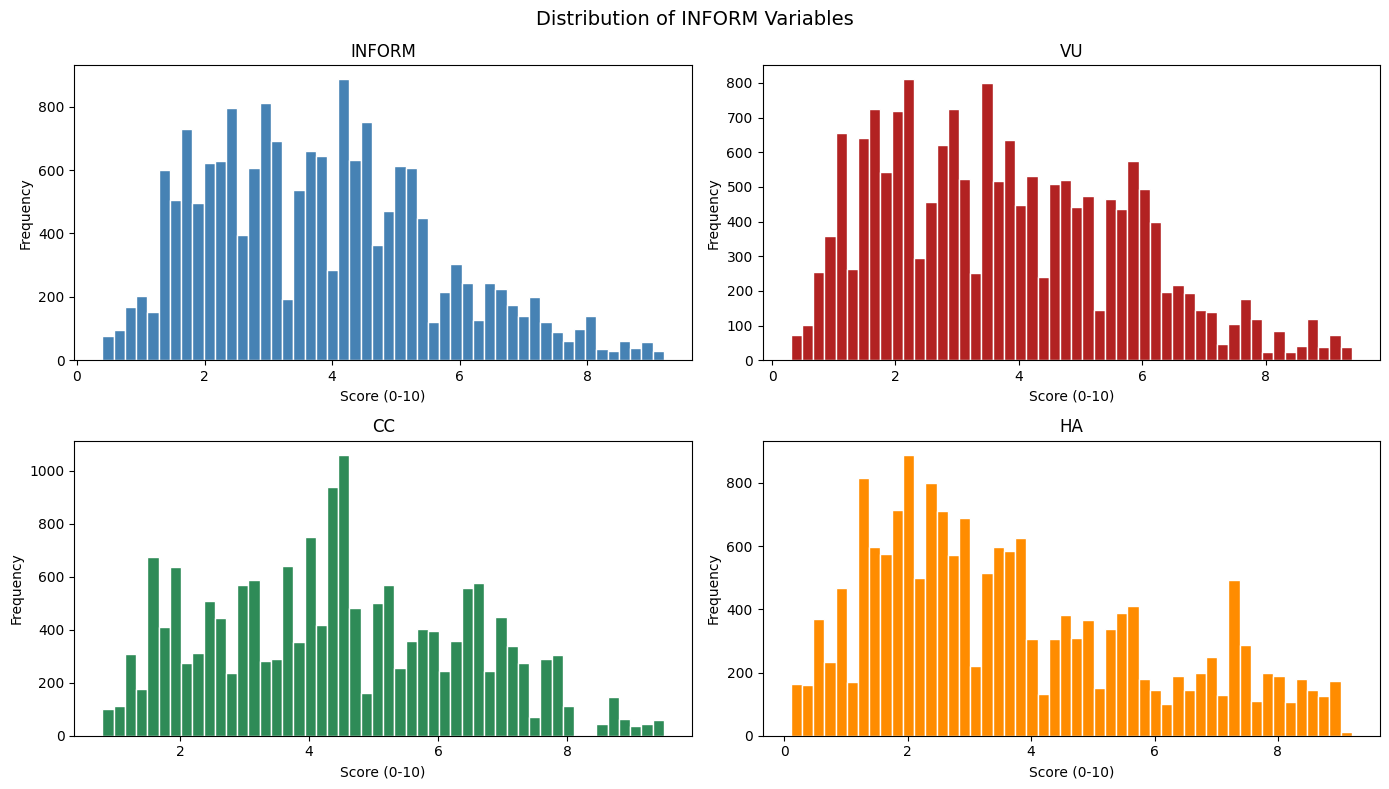

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution of INFORM Variables', fontsize=14)

colors = ['steelblue', 'firebrick', 'seagreen', 'darkorange']

for i, col in enumerate(inform_cols):
    ax = axes[i//2, i%2]
    ax.hist(df[col].dropna(), bins=50, color=colors[i], edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Score (0-10)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Unlike ACLED and IDMC, INFORM variables show no extreme skew , scores are distributed across the full 0-10 scale, reflecting structural differences between countries rather than event-driven spikes. `INFORM` and `CC` are concentrated in the mid-range (2-5), while `VU` is more uniformly distributed. `HA` shows a bimodal pattern, suggesting two distinct groups of countries, those with low hazard exposure and those with very high exposure.

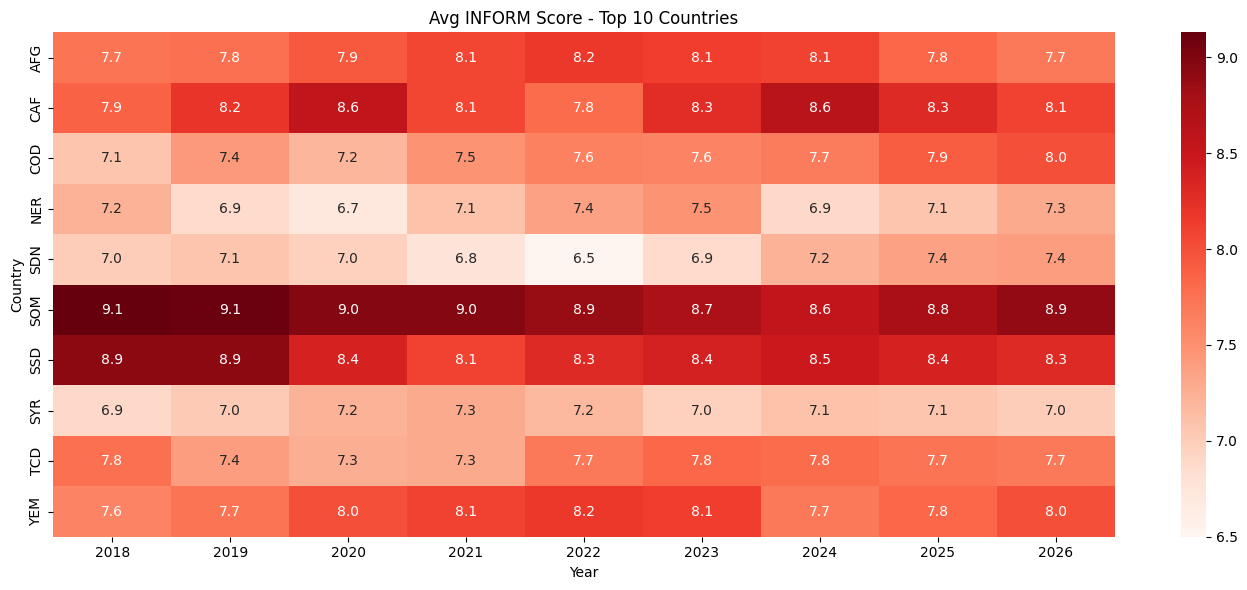

In [4]:
import seaborn as sns

df['year'] = pd.to_datetime(df['month']).dt.year

# Top 10 countries by average INFORM score
top10_inform = df.groupby('iso3')['INFORM'].mean().nlargest(10).index

yearly_inform = df[df['iso3'].isin(top10_inform)].groupby(['year', 'iso3'])['INFORM'].mean().round(2)

pivot_inform = yearly_inform.unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_inform, cmap='Reds', fmt='.1f', annot=True, ax=ax)
ax.set_title('Avg INFORM Score - Top 10 Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()

### Part 2: Bivariate Analysis
This section examines whether countries that are allocation-eligible show systematically higher INFORM scores. Since INFORM captures structural vulnerability rather than active conflict, the expectation is that eligible countries present higher risk scores across all four dimensions, confirming that chronic vulnerability is a precondition for humanitarian crises.

In [5]:
# Mean INFORM variables by allocation-eligible
df.groupby('allocation-eligible')[['INFORM', 'VU', 'CC', 'HA']].mean().round(2)

,INFORM,VU,CC,HA
allocation-eligible,,,,
0,3.67,3.64,4.36,3.55
1,6.96,7.04,6.82,7.22


Total onsets: 98


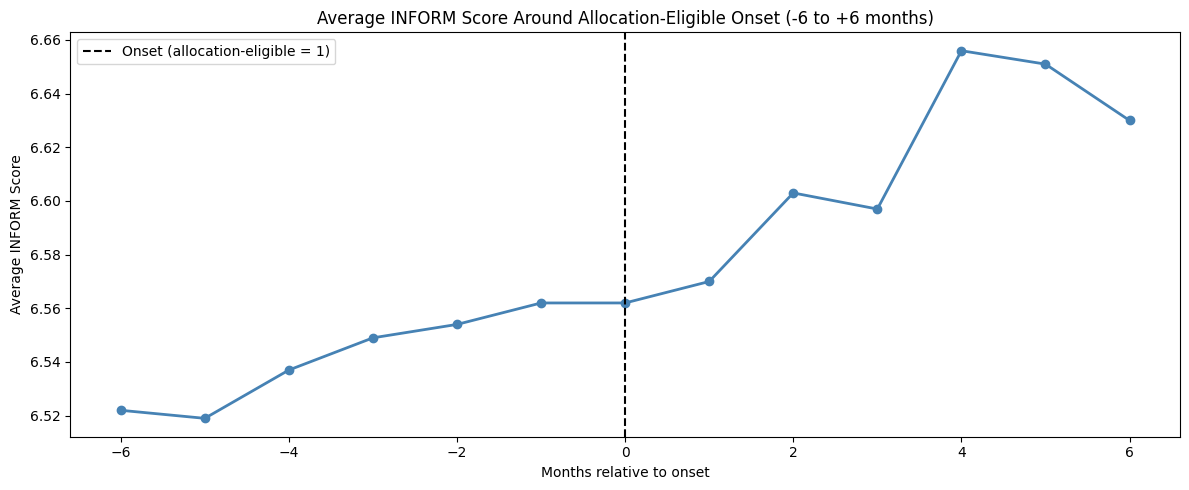

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('../data_clean/final_data.csv')
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values(['iso3', 'month'])

# Build onset
df['prev_eligible'] = df.groupby('iso3')['allocation-eligible'].shift(1)
onset = df[(df['allocation-eligible'] == 1) & (df['prev_eligible'] == 0)][['iso3', 'month']].copy()
print(f"Total onsets: {len(onset)}")

# Window around onset for INFORM
windows_inform = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows_inform.append({'months_to_onset': t,
                                   'INFORM': match['INFORM'].values[0]})

window_df_inform = pd.DataFrame(windows_inform)
avg_inform = window_df_inform.groupby('months_to_onset')['INFORM'].mean().round(3)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_inform.index, avg_inform.values, color='steelblue', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average INFORM Score Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average INFORM Score')
ax.legend()
plt.tight_layout()
plt.show()

The INFORM score rises from 6.52 at t-6 to 6.56 at the onset, and continues increasing after the crisis begins, reaching 6.65 at t+4. This suggests that allocation-eligible countries are not only structurally more vulnerable before the crisis, but that their risk scores tend to worsen once the crisis is underway. Unlike EconAI and ACLED, the variation is small in magnitude , INFORM captures chronic structural risk that changes slowly over time, rather than acute conflict signals. This confirms its role as a background risk indicator rather than an early warning trigger.